In [ ]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 39.5 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.2 which is incompatible.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.2 which is incompatible.
db-dtypes 1.5.1 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.2 which is incompatible.


Fetching record 208 from PhysioNet...
Denoising signal via Discrete Wavelet Transform (DWT)...
Extracting clinical features and running diagnostics...

🩺 AUTOMATED CLINICAL REPORT
Total Heartbeats Detected: 18
Average Heart Rate:        95.6 BPM
-> Normal Heart Rate (95.6 BPM)
-> Arrhythmia Alert: 12 instances of high beat-to-beat variance.

Visualizing the results...


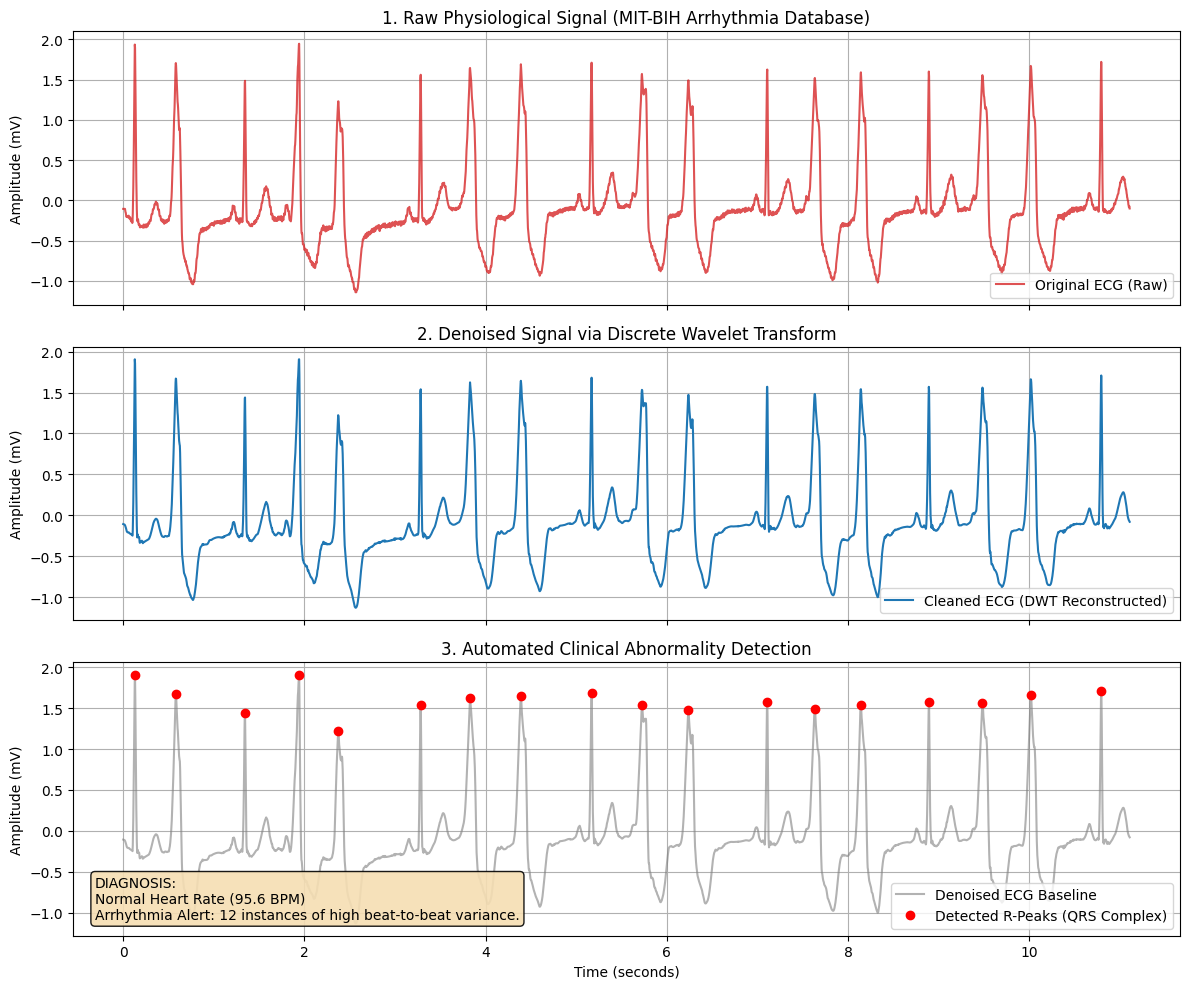

In [ ]:
import wfdb
import pywt
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# ==========================================
# MODULE 1: DATA ACQUISITION
# ==========================================
def fetch_ecg_data(record_name: str = '208', num_samples: int = 4000) -> tuple:
    """Fetches raw ECG data from the PhysioNet database."""
    print(f"Fetching record {record_name} from PhysioNet...")
    fs = 360  # Sampling frequency in Hz for MIT-BIH
    record = wfdb.rdrecord(record_name, pn_dir='mitdb', sampto=num_samples)

    raw_signal = record.p_signal[:, 0]
    time = np.arange(len(raw_signal)) / fs

    return time, raw_signal, fs

# ==========================================
# MODULE 2: SIGNAL PROCESSING (DWT)
# ==========================================
def apply_dwt_denoising(raw_signal: np.ndarray, wavelet: str = 'db4', level: int = 4) -> np.ndarray:
    """Applies Discrete Wavelet Transform (DWT) to strip out high-frequency noise."""
    print("Denoising signal via Discrete Wavelet Transform (DWT)...")
    coeffs = pywt.wavedec(raw_signal, wavelet, level=level)

    # Estimate noise variance and calculate universal threshold
    sigma = np.median(np.abs(coeffs[-1] - np.median(coeffs[-1]))) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(raw_signal)))

    # Apply soft thresholding
    denoised_coeffs = [coeffs[0]] + [pywt.threshold(c, value=uthresh, mode='soft') for c in coeffs[1:]]

    # Reconstruct the signal
    clean_signal = pywt.waverec(denoised_coeffs, wavelet)[:len(raw_signal)]
    return clean_signal

# ==========================================
# MODULE 3: FEATURE EXTRACTION & DIAGNOSTICS
# ==========================================
def extract_and_diagnose(clean_signal: np.ndarray, fs: int) -> tuple:
    """Extracts R-peaks and flags biological abnormalities."""
    print("Extracting clinical features and running diagnostics...")

    # 1. Feature Extraction (R-Peak Detection)
    min_height = np.mean(clean_signal) + (1.5 * np.std(clean_signal))
    min_distance_samples = int(0.3 * fs)

    peaks, _ = find_peaks(clean_signal, height=min_height, distance=min_distance_samples)

    # 2. Diagnostic Logic Engine
    rr_intervals = np.diff(peaks) / fs
    avg_bpm = 60 / np.mean(rr_intervals)

    abnormalities = []

    # Heart rate bounds
    if avg_bpm > 100:
        abnormalities.append(f"Tachycardia Detected (High Avg HR: {avg_bpm:.1f} BPM)")
    elif avg_bpm < 60:
        abnormalities.append(f"Bradycardia Detected (Low Avg HR: {avg_bpm:.1f} BPM)")
    else:
        abnormalities.append(f"Normal Heart Rate ({avg_bpm:.1f} BPM)")

    # Arrhythmia variance bounds
    rr_diffs = np.abs(np.diff(rr_intervals))
    irregular_beats = np.where(rr_diffs > 0.12)[0]

    if len(irregular_beats) > 0:
        abnormalities.append(f"Arrhythmia Alert: {len(irregular_beats)} instances of high beat-to-beat variance.")

    return peaks, avg_bpm, abnormalities

# ==========================================
# MODULE 4: VISUALIZATION
# ==========================================
def plot_pipeline_results(time: np.ndarray, raw_signal: np.ndarray, clean_signal: np.ndarray, peaks: np.ndarray, abnormalities: list):
    """Plots the noisy signal, cleaned signal, and detection results."""
    print("Visualizing the results...")

    # Share X-axis so zooming in on one plot zooms in on all of them simultaneously
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

    # 1. Noisy Signal Plot
    axes[0].plot(time, raw_signal, color='#d62728', alpha=0.8, label='Original ECG (Raw)')
    axes[0].set_title('1. Raw Physiological Signal (MIT-BIH Arrhythmia Database)')
    axes[0].set_ylabel('Amplitude (mV)')
    axes[0].legend(loc='lower right') # Moved to lower right corner
    axes[0].grid(True)

    # 2. Cleaned Signal Plot
    axes[1].plot(time, clean_signal, color='#1f77b4', label='Cleaned ECG (DWT Reconstructed)')
    axes[1].set_title('2. Denoised Signal via Discrete Wavelet Transform')
    axes[1].set_ylabel('Amplitude (mV)')
    axes[1].legend(loc='lower right') # Moved to lower right corner
    axes[1].grid(True)

    # 3. Detection Results Plot
    axes[2].plot(time, clean_signal, color='#7f7f7f', alpha=0.6, label='Denoised ECG Baseline')
    axes[2].plot(time[peaks], clean_signal[peaks], "ro", markersize=6, label='Detected R-Peaks (QRS Complex)')

    # Move the diagnostic text box to the LOWER-LEFT corner
    # X=0.02 (slightly off left edge), Y=0.05 (slightly off bottom edge)
    diagnostic_text = "DIAGNOSIS:\n" + "\n".join(abnormalities)
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.9)
    axes[2].text(0.02, 0.05, diagnostic_text, transform=axes[2].transAxes,
                   fontsize=10, verticalalignment='bottom', bbox=props)

    axes[2].set_title('3. Automated Clinical Abnormality Detection')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].set_ylabel('Amplitude (mV)')
    axes[2].legend(loc='lower right') # Moved to lower right corner
    axes[2].grid(True)

    plt.tight_layout()
    plt.savefig('assets/clinical_detection_results.png', dpi=300)
    plt.show()

# ==========================================
# MAIN FUNCTION
# ==========================================
def main():
    # Execute the modular pipeline
    time, raw_signal, fs = fetch_ecg_data()
    clean_signal = apply_dwt_denoising(raw_signal)
    peaks, avg_bpm, abnormalities = extract_and_diagnose(clean_signal, fs)

    # Print Diagnostics to Terminal
    print("\n" + "="*50)
    print("🩺 AUTOMATED CLINICAL REPORT")
    print("="*50)
    print(f"Total Heartbeats Detected: {len(peaks)}")
    print(f"Average Heart Rate:        {avg_bpm:.1f} BPM")
    for anomaly in abnormalities:
        print(f"-> {anomaly}")
    print("="*50 + "\n")

    # Generate multi-panel visualization
    plot_pipeline_results(time, raw_signal, clean_signal, peaks, abnormalities)

if __name__ == "__main__":
    main()